<a href="https://colab.research.google.com/github/ecloguehwang/2026-Seojinhyeop-Workshop/blob/main/00%EB%8C%80%ED%95%99%EA%B5%90%EB%A1%9C%EB%81%9D%EB%82%98%EB%8A%94%ED%95%A9%EB%B6%88%EC%9E%90%EB%A3%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#colab에서 matplotlib와 sns 라이브러리 그래프 한글을 깨지지 않게 하는 법A: 이 코드실행하고 런타임(runtime) 다시 실행하기
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

In [ ]:
#pandas, openpyxl 라이브러리 부르기
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt


#matplotlib에서 한글구현
plt.rc('font', family='NanumBarunGothic')

#그래프 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False



##  데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2026_habbul.xlsx')


# 첫 5줄을 봅니다.
df.tail(2)

In [ ]:
#합불자료 인원: 134명

df_number = df.drop_duplicates('이름')
df_number = len(df_number)
print(f'2026학년도 중복제외한 합불자료 인원은 {df_number}명임')

In [ ]:
#1. 서울주요대(18개대) 대학별 합격건수

import os
import pandas as pd



uni = ['서울대학교', '연세대학교', '고려대학교', '서강대학교', '성균관대학교', '한양대학교', '중앙대학교', '경희대학교(국제)',
       '한국외국어대학교', '서울시립대학교', '이화여자대학교', '건국대학교', '동국대학교', '홍익대학교', '숙명여자대학교',
       '국민대학교', '숭실대학교', '세종대학교']


# 서울 주요대학 수시합격자수 출력
print("\n***202학년도  합격건수***")

total_accepted = 0  # Variable to store the total number of accepted students

for u in range(len(uni)):
    df_u = df[(df.대학 == uni[u]) & (df.최종 == '합')]
    accepted_count = len(df_u['대학'])
    total_accepted += accepted_count
    print(uni[u], str(accepted_count) + "건")

print(f"\n총 합격자 수: {total_accepted}건")

In [ ]:
#2.수시, 정시별 서울주요대 합격자 명단

import pandas as pd
import matplotlib.pyplot as plt


#표시할 대학리스트
uni = ['서울대학교', '연세대학교', '고려대학교', '서강대학교', '성균관대학교', '한양대학교', '중앙대학교', '경희대학교(국제)',
       '한국외국어대학교', '서울시립대학교', '이화여자대학교', '건국대학교', '동국대학교', '홍익대학교', '숙명여자대학교',
       '국민대학교', '숭실대학교', '세종대학교']


# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2026_habbul.xlsx')


# '지원시기'열의 값 변경: 가,나
df['지원시기'] = df['지원시기'].replace({'정시(가)': '정시', '정시(나)': '정시', '정시(다)': '정시',
                                       '수시1차': '수시', '수시2차': '수시'})

# 빈 리스트
uni_new = []
num_su = []
num_je = []


# 리스트에 새로운 대학리스트와, 수시합격자, 정시합격자를 담기
for u in uni:
    df_u = df[(df.대학 == u) & (df.최종 == '합')]
    df_u = df_u[['지원시기', '학번', '대학', '최종']]

    num_su_u = len(df_u[df_u['지원시기'] == '수시'])
    num_je_u = len(df_u[df_u['지원시기'] == '정시'])


    if num_su_u >= 1 or num_je_u >= 1:  # '지원시기'열의 값이 1 이상일 때만 값을 표시
        uni_new.append(u)
        num_su.append(num_su_u)
        num_je.append(num_je_u)

        print(u, "합격자수 - 수시:", str(num_su_u) + "명,", "정시:", str(num_je_u) + "명")
        print("-----------------------------------------\n")

/tmp/ipykernel_3247/3142676225.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


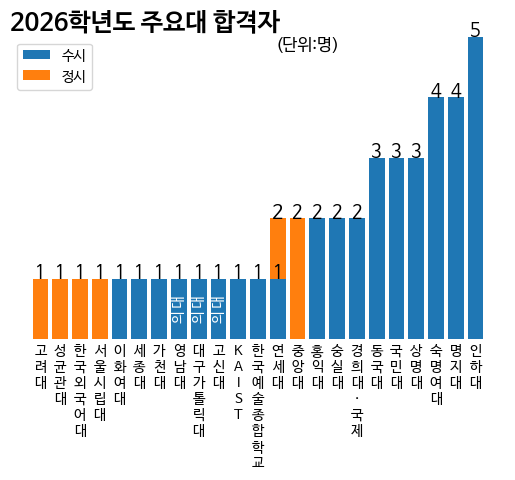

In [ ]:
# 5. 서울주요대 합격자수 막대그래프(세로)

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2026_habbul.xlsx')

# 표시할 대학리스트
uni = ['가천대(메디컬)', '인하대', '순천향대', '충북대', '서울대', '연세대', '고려대', '서강대', '성균관대', '한양대', '중앙대',
       '한국외국어대', '서울시립대', '이화여자대', '건국대', '동국대', '홍익대',
       '숙명여자대', '국민대', '숭실대', '세종대', '서울과기대', '광운대', '명지대', '상명대', '가톨릭대(성심)', '가천대',
       '영남대', '대구가톨릭대', '고신대']

uni = [u + "학교" for u in uni]
uni = uni + ['한국과학기술원(KAIST)', '한국예술종합학교', '경희대학교(국제)']

# 지원시기 통합
df['지원시기'] = df['지원시기'].replace({
    '정시(가)': '정시', '정시(나)': '정시', '정시(다)': '정시',
    '수시1차': '수시', '수시2차': '수시'
})

# 빈 리스트
uni_new = []
num_su = []
num_je = []

# 데이터 집계
for u in uni:
    df_u = df[(df.대학 == u) & (df.최종 == '합')]
    df_u = df_u[['지원시기', '학번', '대학', '최종']]

    num_su_u = len(df_u[df_u['지원시기'] == '수시'])
    num_je_u = len(df_u[df_u['지원시기'] == '정시'])

    if num_su_u >= 1 or num_je_u >= 1:
        uni_new.append(u)
        num_su.append(num_su_u)
        num_je.append(num_je_u)

# 필터링
filtered = [(u, su, je) for u, su, je in zip(uni_new, num_su, num_je) if su >= 1 or je >= 1]

if len(filtered) > 0:
    # 정렬 (총합 기준)
    data = sorted(filtered, key=lambda x: x[1] + x[2])

    uni_new = [x[0] for x in data]
    num_su = [x[1] for x in data]
    num_je = [x[2] for x in data]

    # ── 그래프 표시용 대학명 변환 ──
    def format_uni_name(u):
        if u == '한국예술종합학교':
            return u
        if u == '한국과학기술원(KAIST)':
            return 'KAIST'

        name = u.replace('학교', '')
        name = name.replace('숙명여자대', '숙명여대')
        name = name.replace('이화여자대', '이화여대')

        if name == '경희대(국제)':
            return '경희대·국제'

        return name

    uni_display = [format_uni_name(u) for u in uni_new]

    # 그래프
    fig, ax = plt.subplots()

    ax.bar(uni_display, num_su, label='수시')
    ax.bar(uni_display, num_je, bottom=num_su, label='정시')

    # ✅ 라벨 표시 (조건 반영 핵심)
    for i, (su, je) in enumerate(zip(num_su, num_je)):

        # ① 수시만 있는 경우
        if su >= 1 and je == 0:
            ax.text(i, su + 0.1, su,
                    ha='center', va='center', fontsize=13)

        # ② 정시만 있는 경우
        elif su == 0 and je >= 1:
            ax.text(i, je + 0.1, je,
                    ha='center', va='center', fontsize=13)

        # ③ 수시 + 정시 모두 있는 경우
        elif su >= 1 and je >= 1:
            # 아래쪽: 수시
            ax.text(i, su + 0.1, su,
                    ha='center', va='center', fontsize=13)

            # 위쪽: 합계만 표시 (핵심)
            total = su + je
            ax.text(i, total-0.065, total,
                    ha='center', va='bottom',
                    fontsize=14)
                    #fontsize=14, fontweight='bold')

    # 의대 표시
    for i, (uni, su, je) in enumerate(zip(uni_new, num_su, num_je)):
        if uni in ['영남대학교', '대구가톨릭대학교', '고신대학교']:
            ax.text(i + 0.08, su - 0.5, '의 대',
                    ha='center', va='center',
                    fontsize=10, color='white', rotation=90)

    # 범례
    ax.legend()

    # 제목
    ax.set_title('2026학년도 주요대 합격자',
                 fontsize=18, fontweight='bold', loc='left')

    # 부제목
    ax.text(0.6, 1.00, '(단위:명)',
            ha='center', va='top',
            transform=ax.transAxes, fontsize=12)

    # X축 설정
    ax.tick_params(axis='x', which='both', length=0)

    plt.xticks(rotation=0, ha='center', va='top')
    labels = ax.get_xticklabels()
    for label in labels:
        label.set_rotation(0)
        label.set_text('\n'.join(label.get_text()))

    ax.set_xticklabels(labels)

    # 스타일
    plt.box(False)
    plt.yticks([])

    plt.subplots_adjust(bottom=0.25)

    plt.show()

else:
    print("아쉽게도 그래프를 그릴 합격자가 없습니다.")

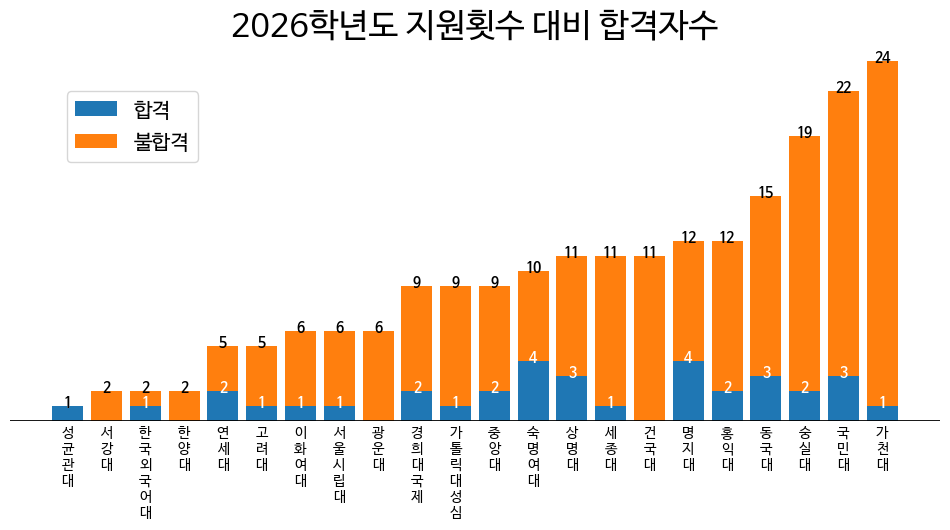

In [ ]:
#6. 서울주요대 합격자 및 불합격자 누적 세로 막대그래프

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FixedLocator

# 데이터 부르기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2026_habbul.xlsx')


uni = ['서울대학교', '연세대학교', '고려대학교', '서강대학교', '성균관대학교', '한양대학교', '중앙대학교', '경희대학교(국제)',
       '한국외국어대학교', '서울시립대학교', '이화여자대학교', '건국대학교', '동국대학교', '홍익대학교', '숙명여자대학교',
       '국민대학교', '숭실대학교', '세종대학교', '단국대학교', '광운대학교', '명지대학교', '상명대학교', '가천대학교', '가톨릭대학교(성심)']


# create a new DataFrame containing the number of applications and acceptance for each university
num_applications = []
num_acceptance = []
for u in uni:
    # ── 가천대학교: 가천대학교 + 가천대학교(메디컬) 합산 ──────────────
    if u == '가천대학교':
        uni_admissions = df[df['대학'].isin(['가천대학교', '가천대학교(메디컬)'])]
    else:
        uni_admissions = df[df['대학'] == u]

    num_app = len(uni_admissions)
    num_acc = len(uni_admissions[uni_admissions['최종'] == '합'])
    num_applications.append(num_app)
    num_acceptance.append(num_acc)

admission_df = pd.DataFrame({'대학': uni, '지원건수': num_applications, '합격건수': num_acceptance})


# 빈도가 0인 경우 해당 label을 x축 label에서 제거
admission_df = admission_df[admission_df['지원건수'] != 0]

# 그래프를 오름차순으로 정렬하기
admission_df = admission_df.sort_values('지원건수')


# ── 그래프 표시용 대학명 변환 ─────────────────────────────────────
def format_uni_name(u):
    if u == '경희대학교(국제)':
        return '경희대·국제'
    if u == '가톨릭대학교(성심)':
        return '가톨릭대·성심'
    if u == '가천대학교(글로벌)':
        return '가천대·글로벌'
    name = u.replace('학교', '')
    name = name.replace('숙명여자대', '숙명여대')
    name = name.replace('이화여자대', '이화여대')
    return name

uni_display = [format_uni_name(u) for u in admission_df['대학']]


# create a vertical stacked bar plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x=range(len(admission_df)), height='합격건수', data=admission_df, bottom=0, label='합격')
ax.bar(x=range(len(admission_df)), height=admission_df['지원건수'] - admission_df['합격건수'],
       data=admission_df, bottom=admission_df['합격건수'], label='불합격')


# ── x축 레이블 세로로 쓰기 (FixedLocator로 경고 방지) ────────────────
ax.xaxis.set_major_locator(FixedLocator(range(len(uni_display))))

def name_to_vertical(name):
    if '·' in name:
        parts = name.split('·')
        return '\n'.join(parts[0]) + '\n' + '\n'.join(parts[1])
    return '\n'.join(name)

ax.set_xticklabels(
    [name_to_vertical(name) for name in uni_display],
    rotation=0, ha='center', va='top'
)


ax.set_title('2026학년도 지원횟수 대비 합격자수', fontsize=24)

# add labels on top of the bars
for i, v in enumerate(admission_df['합격건수']):
    if v > 0:
        ax.text(i, v, str(v), color='white', ha='center', fontweight='bold')

for a, b in enumerate(admission_df['지원건수']):
    if b > 0:
        ax.text(a, b, str(b), color='black', ha='center', fontweight='bold')

# y축 제거
ax.set_yticks([])

# remove ticks and spines
ax.tick_params(axis='y', which='both', length=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# create a horizontal line on the x-axis
ax.axhline(y=0, color='black', linewidth=2)

# move the legend
ax.legend(fontsize=15, loc='upper left', bbox_to_anchor=(0.05, 0.9))

# X축 눈금(ticks) 제거
ax.tick_params(axis='x', which='both', length=0)

plt.subplots_adjust(bottom=0.25)

plt.show()

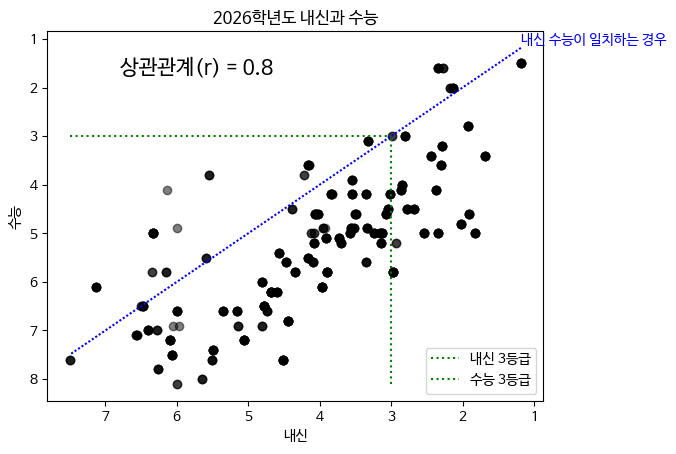

In [ ]:
#9-7. 내신과 수능과 상관관계D: 산포도에 1:1대응 직선

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Drop rows with any NaN values in '전과목' or '등급수능' columns
df = df.dropna(subset=['전과목', '등급수능'])

# Extract '전과목' and '등급수능' columns
x = df['전과목'].values
y = df['등급수능'].values

# Calculate the correlation coefficient
corr_coef = np.corrcoef(x, y)[0, 1]

# Create the scatter plot
plt.scatter(x, y, alpha=0.5, c='black')
plt.title('2026학년도 내신과 수능')
plt.xlabel('내신')
plt.ylabel('수능')

# Add the correlation coefficient to the plot
plt.text(0.3, 0.9, f'상관관계(r) = {corr_coef:.1f}',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=15)

# Reverse the x-axis and y-axis
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()

# Add a 1:1 line
plt.plot([min(x), max(x)], [min(x), max(x)], color='blue', linestyle='--', dashes=[1, 1])

# Add text for the 1:1 line
plt.text(min(x), min(x), '내신 수능이 일치하는 경우', color='blue', verticalalignment='bottom')


# Vertical line from x=3 (top of chart) down to intersection point (3, 3)
plt.plot([3, 3], [max(y), 3], color='green', linestyle=':', linewidth=1.5, label='내신 3등급')


# Horizontal line from y=3 (left of chart) to intersection point (3, 3)
plt.plot([max(x), 3], [3, 3], color='green', linestyle=':', linewidth=1.5, label='수능 3등급')

plt.legend()
plt.show()

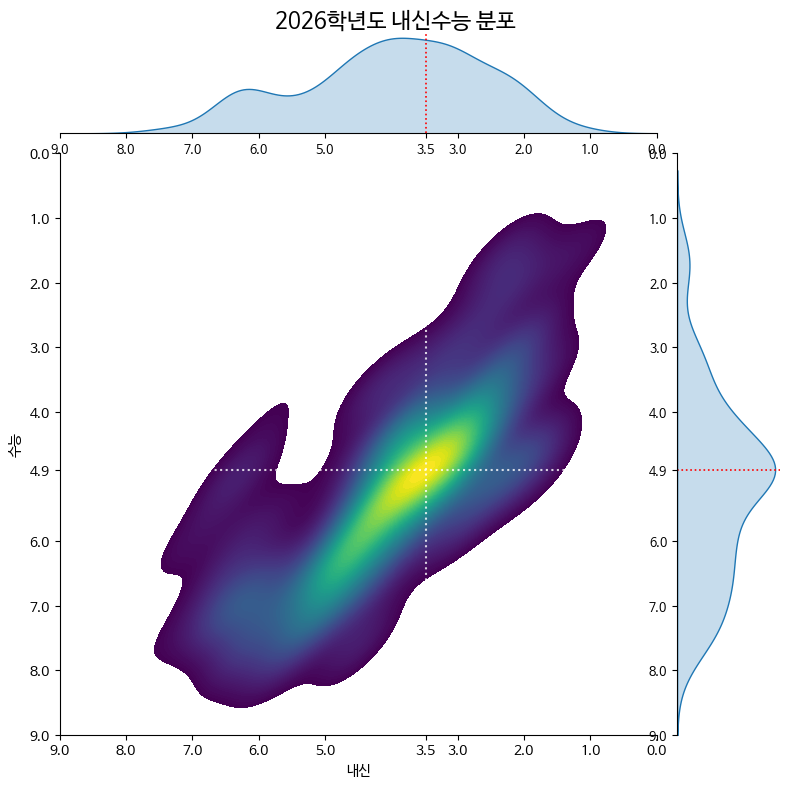

In [ ]:
# 내신과 수능의 최대 밀도 표시 (X축 4.0, Y축 5.0 제외 버전)

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

# 1. 데이터 전처리
df = df.dropna(subset=['전과목', '등급수능'])
x = df['전과목'].values
y = df['등급수능'].values
corr_coef = np.corrcoef(x, y)[0, 1]

# 2. jointplot 생성
g = sns.jointplot(
    data=df, x='전과목', y='등급수능', kind='kde',
    fill=True, cmap='viridis', thresh=0.05, levels=100, height=8
)

# 3. 가장 밀도가 높은 지점(Mode) 찾기
values = np.vstack([x, y])
kernel = gaussian_kde(values)
gx, gy = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]
positions = np.vstack([gx.ravel(), gy.ravel()])
z = np.reshape(kernel(positions).T, gx.shape)

idx = np.argmax(z)
max_x = gx.ravel()[idx]
max_y = gy.ravel()[idx]

# 4. 축 범위 및 반전 설정 (X, Y축 모두 0 ~ 9)
ax = g.ax_joint
ax.set_xlim(0, 9)
ax.set_ylim(0, 9)

# 양축 반전: 9(좌/하) -> 0(우/상) 순서로 배치
ax.invert_xaxis()
ax.invert_yaxis()

g.set_axis_labels('내신', '수능')
plt.suptitle('2026학년도 내신수능 분포', fontsize=16)
plt.subplots_adjust(top=0.95)

# ── 눈금 설정 함수 (특정 값 제외 로직 포함) ───────────────────
def set_custom_ticks_final(ax, mode_val, axis='x', exclude_val=None):
    # 0부터 9까지 1단위 기본 눈금
    base_ticks = list(np.arange(0, 10, 1).astype(float))

    # 특정 값(4.0 또는 5.0) 제외 로직 적용
    if exclude_val is not None:
        # 부동 소수점 오차를 고려하여 0.1 차이 이내인 경우 제외
        final_ticks = [t for t in base_ticks if abs(t - exclude_val) > 0.1]
    else:
        final_ticks = base_ticks

    final_ticks.append(mode_val)
    final_ticks.sort()

    if axis == 'x':
        ax.set_xticks(final_ticks)
        ax.set_xticklabels([f"{t:.1f}" for t in final_ticks])
    else:
        ax.set_yticks(final_ticks)
        ax.set_yticklabels([f"{t:.1f}" for t in final_ticks])


# ✅ [수정 포인트] X축은 4.0 제외, Y축은 5.0 제외하여 최대밀도 지점 강조
#set_custom_ticks_final(ax, max_x, axis='x', exclude_val=4.0)
set_custom_ticks_final(ax, max_y, axis='y', exclude_val=5.0)

# ── 주변 분포 및 가이드 점선 ────────────────────────────
# 메인 그래프 점선
ax.axvline(max_x, color='white', linestyle=':', linewidth=1.5, alpha=0.8)
ax.axhline(max_y, color='white', linestyle=':', linewidth=1.5, alpha=0.8)

# 주변 분포 축 범위 동기화
g.ax_marg_x.set_xlim(ax.get_xlim())
g.ax_marg_y.set_ylim(ax.get_ylim())

# 주변 분포 가이드 라인 (빨간 점선)
g.ax_marg_x.axvline(max_x, color='red', linestyle=':', linewidth=1.2)
g.ax_marg_y.axhline(max_y, color='red', linestyle=':', linewidth=1.2)

# 주변 분포 눈금 표시 설정
g.ax_marg_x.xaxis.set_tick_params(labelbottom=True)
g.ax_marg_y.yaxis.set_tick_params(labelleft=True)

# 주변 분포 눈금에서도 제외 로직 반영 (가독성 유지)
def set_marg_ticks(marg_ax, mode_val, axis='x', exclude_val=None):
    base_ticks = list(np.arange(0, 10, 1).astype(float))
    if exclude_val is not None:
        ticks = [t for t in base_ticks if abs(t - exclude_val) > 0.1]
    else:
        ticks = base_ticks
    ticks.append(mode_val)
    ticks.sort()

    if axis == 'x':
        marg_ax.set_xticks(ticks)
        marg_ax.set_xticklabels([f"{t:.1f}" for t in ticks], fontsize=9)
    else:
        marg_ax.set_yticks(ticks)
        marg_ax.set_yticklabels([f"{t:.1f}" for t in ticks], fontsize=9)

set_marg_ticks(g.ax_marg_x, max_x, axis='x', exclude_val=4.0)
set_marg_ticks(g.ax_marg_y, max_y, axis='y', exclude_val=5.0)

plt.show()

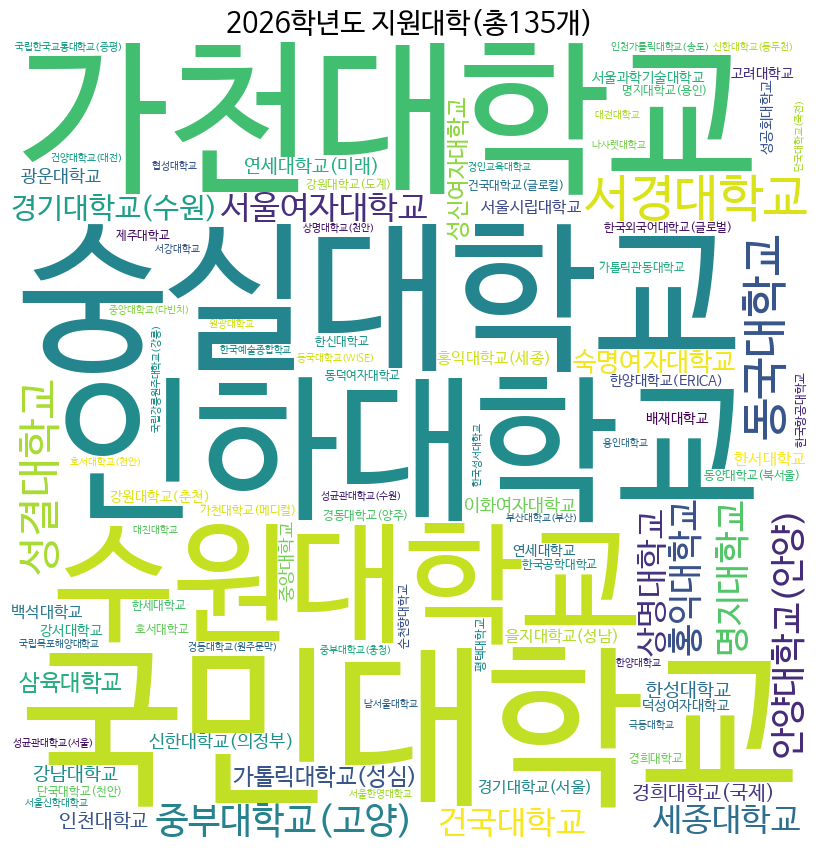

In [ ]:
#13.지원대학 워드클라우드(wordcloud)

import random
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import datetime

# Get the current year
current_year = datetime.datetime.now().year


# Assuming the academic year starts this year and continues into the next year
academic_year = f"{current_year}학년도"


#지원시기: 수시
df_apply = df[df.지원시기  == '수시']



#중복제외한 대학수
df_dup = df_apply.drop_duplicates('대학')
df_freq = len(df_dup['대학'])



#결과를 하나로 고정
random.seed(42)  # set the random seed



wordcloud = WordCloud(font_path='NanumBarunGothic', width=800, height=800, background_color='white', min_font_size=10).generate_from_frequencies(df_apply['대학'].value_counts())


fig = plt.figure(figsize=(8, 8))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)


# Now update the title string to include the current academic year
plt.title(f"{academic_year} 지원대학(총{df_freq}개)", fontsize=20)

path = '/content/drive/MyDrive/python/sumyeong/'
pdf_path = f'{path}2026학년도_수명고_wordcloud.pdf'
plt.savefig(pdf_path, dpi=300, bbox_inches='tight', pad_inches=0)

wordcloud.to_file(f'{path}202학년도_수명고_wordcloud.png')

plt.show()

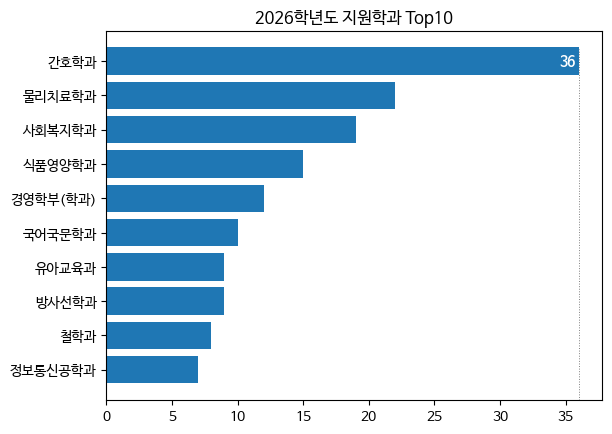

In [ ]:
#14. 지원학과 막대그래프(가로)

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
path = '/content/drive/MyDrive/python/habbul/sumyeong/'
df = pd.read_excel(f'{path}sumyeong_2026_habbul.xlsx')


# '모집단위' 열에서 '경영학과'와 '경영학부'를 '경영학부(학과)'로 합산
df['모집단위'] = df['모집단위'].replace({'경영학과': '경영학부(학과)', '경영학부': '경영학부(학과)', '경영학부(경영학전공)': '경영학부(학과)'})

# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'컴퓨터소프트웨어학과': '컴퓨터과학과', '소프트웨어학과': '컴퓨터과학과',  '컴퓨터공학과': '컴퓨터과학과'})


# '모집단위' 열에서 '국어교육문학' 합산
df['모집단위'] = df['모집단위'].replace({'국어국문문예창작학부': '국어교육문학전공', '국어교육과': '국어교육문학전공'})


# '모집단위' 열에서 '사회복지학과' 합산
df['모집단위'] = df['모집단위'].replace({'사회복지과': '사회복지학과'})


# '모집단위' 열에서 '물리치료과' 합산
df['모집단위'] = df['모집단위'].replace({'물리치료과': '물리치료학과'})



# '모집단위' 열에서 '컴퓨터관련학과' 합산
df['모집단위'] = df['모집단위'].replace({'자유전공': '자유전공학부', '자율설계전공학부': '자유전공학부'})


# Filter the rows based on the frequency of the "대학" column
freq = df['모집단위'].value_counts()
freq = freq[freq >= 7]

# 대학수
freq_num = len(freq)

# Create a horizontal bar plot with descending order
freq_sorted = freq.sort_values()
plt.barh(freq_sorted.index, freq_sorted)



# Draw a dotted vertical line only from the X-axis tick with maximum value of the plot
max_value = max(freq_sorted)
plt.axvline(max_value, linestyle=':', color='gray', linewidth=0.7, ymax=0.95)  # 아래쪽 x축까지 선이 도달하도록 ymax 설정



# Annotate the maximum value on the plot
plt.text(max_value - 1.5, len(freq_sorted) - 1, f'{max_value}', color='white', fontsize=10, va='center', fontweight='bold')



plt.title(f"2026학년도 지원학과 Top{freq_num}")
plt.show()

In [ ]:
#30-2. 내신보다 수능이 더 잘 나온 학생비율

# Filter the DataFrame
filtered_df = df[(df['전과목'] - df['등급수능'] > 0)]
filtered_df = filtered_df.drop_duplicates(subset='이름')


# Round the '전과목' column to two decimal places
filtered_df['전과목'] = filtered_df['전과목'].apply(lambda x: round(x, 1))

filtered_df_total = df.drop_duplicates(subset='이름')
filtered_df_num = len(filtered_df_total)
filtered_df_num_div = (len(filtered_df) / filtered_df_num)*100
filtered_df_num_div = round(filtered_df_num_div, 0)


# Print the filtered DataFrame
print(filtered_df[['전과목', '등급수능']])
print("-----------------------------------------------------")
print(f'2026학년도 내신보다 수능이 잘 나온 학생이 {len(filtered_df)}명이고 비율은 {int(filtered_df_num_div)}%')

     전과목  등급수능
10   2.1   2.0
203  7.1   6.1
346  5.5   3.8
361  6.1   4.1
364  4.2   3.8
406  6.0   4.9
439  6.3   5.0
484  6.3   5.8
507  4.2   3.6
579  3.3   3.1
590  2.3   1.6
760  5.6   5.5
-----------------------------------------------------
2026학년도 내신보다 수능이 잘 나온 학생이 12명이고 비율은 9%


In [ ]:
#등급대별 합격현황

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd



lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))

# 필터링 및 복사
df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum)].copy()

# 피벗 테이블 생성
pivot_data = df_one.pivot_table(index='이름', columns='최종', values='학번', aggfunc='count', fill_value=0)
for col in ['합', '불']:
    if col not in pivot_data.columns:
        pivot_data[col] = 0

pivot_data = pivot_data[['합', '불']]
college_unit_data = df_one.groupby(['이름', '최종']).agg({'대학': lambda x: list(x)}).unstack(fill_value=[])
pivot_data.sort_values(by='합', ascending=True, inplace=True)

# 대학명 단축 함수
def shorten_university_name(name):
    if not isinstance(name, str): return str(name)
    name = name.strip()
    if '한국예술종합학교' in name: return '한예종'
    if '한국외국어' in name and '글로벌' in name: return '외대(글)'
    elif '한국외국어' in name: return '외대'
    return name.replace('대학교', '').replace('대학', '')

# 그래프 생성
plt.figure(figsize=(12, 8))
ax = pivot_data.plot(kind='bar', stacked=True, color=sns.color_palette('Dark2', 2), figsize=(12, 7))
plt.gca().spines[['top', 'right']].set_visible(False)
plt.title(f"2026학년도  {lownum}등급대 학생별 합격현황 (단위: 건)")

# 범례 설정 (에러 수정 포인트: list() 추가)
handles, labels = ax.get_legend_handles_labels()
plt.legend(list(reversed(handles)), list(reversed(labels)), title="최종", loc='upper left', bbox_to_anchor=(1, 1))

# x축 이름 세로 출력
labels_text = [label.get_text() for label in ax.get_xticklabels()]
new_labels = ['\n'.join(list(label)) for label in labels_text]
ax.set_xticklabels(new_labels, rotation=0)

# 텍스트 배치
font_size = 7
text_offset = 0.5

for idx, val in enumerate(pivot_data.index):
    # 합격 대학 (초록색 영역)
    sum_height = pivot_data.loc[val, '합']
    if ('대학', '합') in college_unit_data.columns:
        colleges_won = college_unit_data.loc[val, ('대학', '합')]
        for i, college in enumerate(colleges_won):
            short_name = shorten_university_name(college)
            plt.text(idx, sum_height - (i * text_offset) - 0.2, short_name,
                     ha='center', va='top', color='black', weight='bold', fontsize=font_size, rotation=0)

    # 불합격 대학 (주황색 영역)
    non_height = pivot_data.loc[val, '불']
    if ('대학', '불') in college_unit_data.columns:
        colleges_lost = college_unit_data.loc[val, ('대학', '불')]
        for i, college in enumerate(colleges_lost):
            short_name = shorten_university_name(college)
            plt.text(idx, sum_height + non_height - (i * text_offset) - 0.2, short_name,
                     ha='center', va='top', color='black', fontsize=font_size, rotation=0)

plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

몇등급 이상:1
몇등급 미만:2


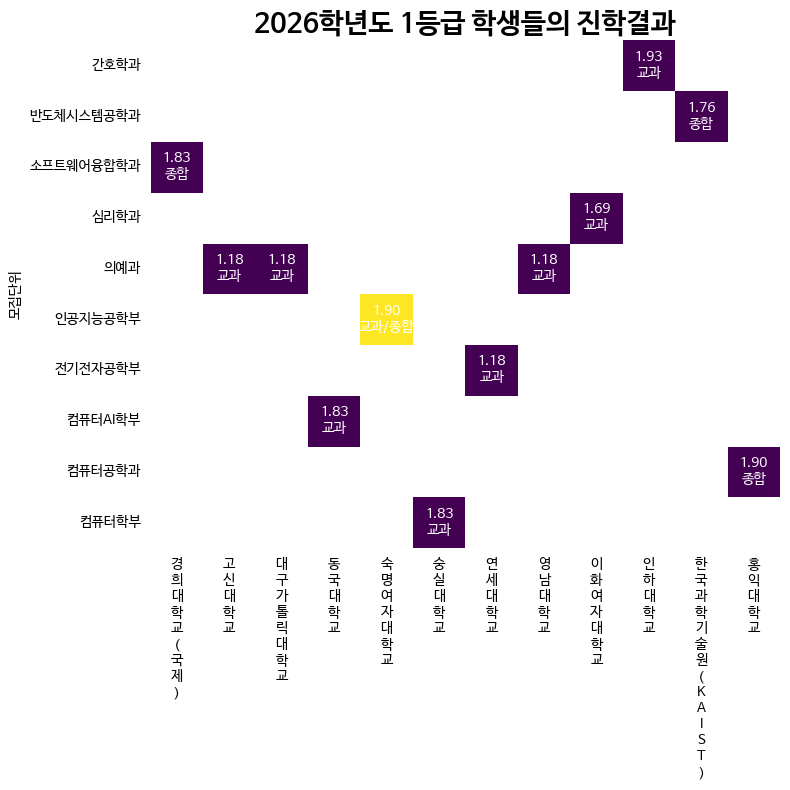

In [ ]:
#40. 특정등급대 학생들의 진학결과 그래프: 창의적 그래프

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

lownum = float(input("몇등급 이상:"))
highnum = float(input("몇등급 미만:"))

# 필터링 조건에 맞는 데이터 추출
df_one = df[(df['전과목'] >= lownum) & (df['전과목'] < highnum) & (df['최종'] == '합')].copy()

plt.figure(figsize=(8, 8))
plt.title(f'2026학년도 {int(round(lownum))}등급 학생들의 진학결과', fontsize=20, fontweight='bold')

# 그룹화 및 모집단위별 카운트
df_2dhist = pd.DataFrame({
    x_label: grp['모집단위'].value_counts()
    for x_label, grp in df_one.groupby('대학')
})

# ── 핵심 추가 부분 ──────────────────────────────────────────────
# 각 셀(대학 × 모집단위)에 표시할 전과목 평균 + 전형분류 수집
annot_text = pd.DataFrame(
    index=df_2dhist.index,
    columns=df_2dhist.columns,
    dtype=object
)
annot_text[:] = ''   # 기본값: 빈 문자열

for univ, grp_u in df_one.groupby('대학'):
    if univ not in annot_text.columns:
        continue
    for major, grp_m in grp_u.groupby('모집단위'):
        if major not in annot_text.index:
            continue
        avg_grade = grp_m['전과목'].mean()           # 전과목 평균등급
        types = grp_m['전형분류'].unique()           # 전형분류 목록
        type_str = '/'.join(str(t) for t in types)  # 여러 개면 '/'로 구분
        annot_text.loc[major, univ] = f"{avg_grade:.2f}\n{type_str}"
# ────────────────────────────────────────────────────────────────

# 히트맵 생성 (annot=annot_text 로 커스텀 텍스트 삽입)
ax = sns.heatmap(
    df_2dhist,
    cmap='viridis',
    cbar=False,
    annot=annot_text,   # 커스텀 annotation
    fmt='',             # 문자열이므로 fmt는 빈 문자열
    annot_kws={'fontsize': 10, 'color': 'white'}
)

plt.tick_params(
    axis='both', which='both',
    bottom=False, top=False, left=False, right=False,
    labelbottom=True, labelleft=True
)

plt.xticks(rotation=0, ha='center', va='top')

labels = ax.get_xticklabels()
for label in labels:
    label.set_rotation(0)
    label.set_text('\n'.join(label.get_text()))

ax.set_xticklabels(labels)

plt.tight_layout()
plt.show()

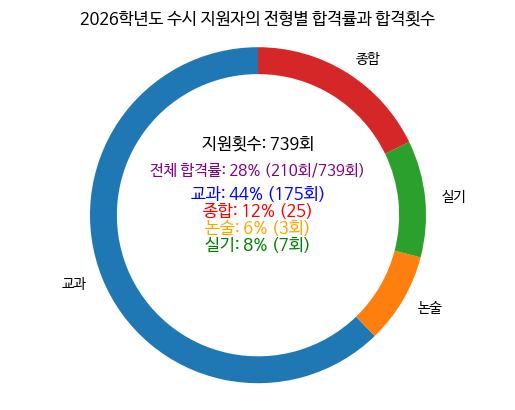

In [ ]:
#52. 전형별 합격률과 합격횟수

import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리: 전형분류 재분류
df_modified = df.copy()


# 조건 1: '전형분류'가 '학생부'이고 '전형방법'에 '100%'가 포함된 경우 → '교과'로 변경
df_modified.loc[(df_modified['전형분류'] == '학생부') &
                (df_modified['전형방법'].str.contains('100%', na=False)), '전형분류'] = '교과'


# 조건 2: '전형분류'가 '학생부'이고 '전형방법'에 '면접'이 포함된 경우 → '종합'으로 변경
df_modified.loc[(df_modified['전형분류'] == '학생부') &
                (df_modified['전형방법'].str.contains('면접', na=False)), '전형분류'] = '종합'


# 수시, 수시1차, 수시2차를 모두 포함
susi = ['수시', '수시1차', '수시2차']

# 조건에 따라 데이터 필터링 (df_modified 사용!)
filtered_df = df_modified[df_modified['지원시기'].str.contains("|".join(susi), na=False)]

# 각 전형분류별 합격자 수 계산
pass_counts = filtered_df.groupby('전형분류')['최종'].value_counts().unstack().fillna(0)['합']

# 각 전형분류별 합격률 계산 (전형분류 내 비율)
pass_rates = filtered_df.groupby('전형분류')['최종'].value_counts(normalize=True).unstack().fillna(0)['합']

# ✅ 추가: 전체 지원횟수 대비 최종 '합' 비율 계산
total_count = len(filtered_df)
total_pass_count = (filtered_df['최종'] == '합').sum()
total_pass_rate = total_pass_count / total_count * 100

# 도넛 차트 생성
labels = pass_rates.index
sizes = pass_rates.values * 100
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, startangle=90, wedgeprops=dict(width=0.16))

ax.axis('equal')

# 도넛 차트 내부에 비율과 빈도 표현
ax.text(0,  0.4, f"지원횟수: {total_count}회", ha='center', fontsize=12, color='black')
ax.text(0,  0.25, f"전체 합격률: {total_pass_rate:.0f}% ({total_pass_count}회/{total_count}회)", ha='center', fontsize=11, color='purple')  # ✅ 추가된 줄
ax.text(0,  0.1, f"교과: {pass_rates['교과'] * 100:.0f}% ({int(pass_counts['교과'])}회)", ha='center', fontsize=12, color='blue')
ax.text(0,  0.0, f"종합: {pass_rates['종합'] * 100:.0f}% ({int(pass_counts['종합'])})", ha='center', fontsize=12, color='red')
ax.text(0, -0.1, f"논술: {pass_rates['논술'] * 100:.0f}% ({int(pass_counts['논술'])}회)", ha='center', fontsize=12, color='orange')
ax.text(0, -0.2, f"실기: {pass_rates['실기'] * 100:.0f}% ({int(pass_counts['실기'])}회)", ha='center', fontsize=12, color='green')

plt.title('2026학년도 수시 지원자의 전형별 합격률과 합격횟수')
plt.show()

In [ ]:
#55. 등급대별 수능최저등급 충족여부 - 내신등급 추가


import numpy as np
import pandas as pd
from tabulate import tabulate
import math  # 절사를 위해 math 모듈 추가

# 입력 받기
level_min = float(input("내신 높은 등급:"))
level_max = float(input("내신 낮은 등급:"))

choice = input("탐구1과 탐구2의 평균등급을 사용하시겠습니까? (예/아니오): ")

# '수능'을 제외한 값 필터링
df_filtered = df[df['전형분류'] != '수능']

# 범위에 따른 '전과목' 값 필터링
df_level = df_filtered[(df_filtered['전과목'] >= level_min) & (df_filtered['전과목'] < level_max)].copy()

# 데이터 프레임 필터링
df_level = df_level.drop_duplicates('이름')
df_level = df_level[['이름', '전과목', '국어_등급', '수학_등급', '영어_등급', '선택1_등급', '선택2_등급']]

# '이름' 열의 값을 첫 글자만 남기고 나머지는 '*'로 대체
#df_level['이름'] = df_level['이름'].apply(lambda x: x[:1] + '*' * (len(x) - 1) if len(x) >= 2 else x)

# 열 이름 변경
df_level.rename(columns={'선택1_등급': '탐구1_등급', '선택2_등급': '탐구2_등급'}, inplace=True)


# NaN 값을 0으로 대체
df_level.fillna(0, inplace=True)

# 평균 사용 여부에 따른 조건 처리
if choice.lower() == '예':
    trunc_choice = input("탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): ")
    if trunc_choice.lower() == '예':
        df_level['탐구_등급'] = df_level[['탐구1_등급', '탐구2_등급']].mean(axis=1).apply(math.floor)
    else:
        df_level['탐구_등급'] = df_level[['탐구1_등급', '탐구2_등급']].mean(axis=1)
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구_등급']
else:
    columns = ['국어_등급', '수학_등급', '영어_등급', '탐구1_등급', '탐구2_등급']

# 최저합 계산
df_level['4합'] = df_level[columns].apply(lambda x: x.nsmallest(4).sum(), axis=1)
df_level['3합'] = df_level[columns].apply(lambda x: x.nsmallest(3).sum(), axis=1)
df_level['2합'] = df_level[columns].apply(lambda x: x.nsmallest(2).sum(), axis=1)

# 결과 출력
headers = ['전과목', '국어_등급', '수학_등급', '영어_등급']
if choice.lower() == '예':
    headers.append('탐구_등급')
else:
    headers.extend(['탐구1_등급', '탐구2_등급'])
headers.extend(['2합', '3합', '4합'])

#전과목 순으로 오름차순
df_level = df_level.sort_values(by='전과목')

tab = tabulate(df_level[headers], headers='keys', tablefmt='plain', showindex=False)
print()
print(tab)


# 엑셀로 저장
path = '/content/drive/MyDrive/python/sumyeong/'
df_level.to_excel(excel_writer=f'{path}{level_min}등급대_수능최저등급조합_2026_수명고_익명.xlsx', index=False)

내신 높은 등급:1
내신 낮은 등급:2
탐구1과 탐구2의 평균등급을 사용하시겠습니까? (예/아니오): 예
탐구1과 탐구2의 평균을 절사하시겠습니까? (예/아니오): 예

  전과목    국어_등급    수학_등급    영어_등급    탐구_등급    2합    3합    4합
   1.184            1            2            1            2      2      4      6
   1.689            3            4            2            4      5      9     13
   1.764            0            0            0            0      0      0      0
   1.83             7            4            3            6      7     13     20
   1.903            9            2            3            4      5      9     18
   1.925            3            3            2            3      5      8     11
